# Phase A — Vérification de cohérence des modèles
## VRPTW — Attention Model (Kool 2019) + REINFORCE

**Architecture réelle** : Transformer encoder (3 couches, 8 têtes, d_h=128) + Attention decoder avec clipping tanh C=10.  
**Environnement** : VRPTW multi-véhicules avec masque dynamique (capacité + time windows).  

**Plan** :
1. Chargement des checkpoints `model_best.pt`
2. Courbes d'apprentissage — vérifier la convergence
3. Test rapide sur n=10 (1 instance à la main)
4. Vérification complète — toutes les tailles
5. Visualisation des chemins multi-véhicules
6. Bilan global + décision feu vert / rouge

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import verification_dl as vdl

print('Torch :', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)

Torch : 2.6.0+cu124
Device : cuda


## 1. Chargement des checkpoints

On charge les `model_best.pt` — le meilleur greedy sauvegardé par `train.py`.  
**Adapte les chemins** si ton arborescence est différente.

In [2]:
CHEMINS = {
    10 : 'checkpoints_n10/model_best.pt',
    20 : 'checkpoints_n20/model_best.pt',
    50 : 'checkpoints_n50/model_best.pt',
    100: 'checkpoints_n100/model_best.pt',
    200: 'checkpoints_n200/model_best.pt',
}

modeles = vdl.charger_tous_les_modeles(CHEMINS, DEVICE)
print(f'\n{len(modeles)} modèle(s) chargé(s) : {sorted(modeles.keys())}')

  [OK] Chargé : model_best.pt  (epoch 194)
       Meilleure greedy entraînement : 481.1
  [OK] Chargé : model_best.pt  (epoch 157)
       Meilleure greedy entraînement : 779.2
  [OK] Chargé : model_best.pt  (epoch 185)
       Meilleure greedy entraînement : 2066.2
  [OK] Chargé : model_best.pt  (epoch 185)
       Meilleure greedy entraînement : 7085.1
  [OK] Chargé : model_best.pt  (epoch 188)
       Meilleure greedy entraînement : 20935.7

5 modèle(s) chargé(s) : [10, 20, 50, 100, 200]


## 2. Courbes d'apprentissage

Avant toute inférence, vérifier que chaque modèle a bien convergé.  
- La courbe **greedy** (bleue) doit descendre et se stabiliser
- La courbe **sample** (grise) doit rester au-dessus ou au niveau de greedy
- Un plateau plat dès les premières epochs = modèle non convergé → à ré-entraîner

Figure sauvegardée : courbes_apprentissage.png


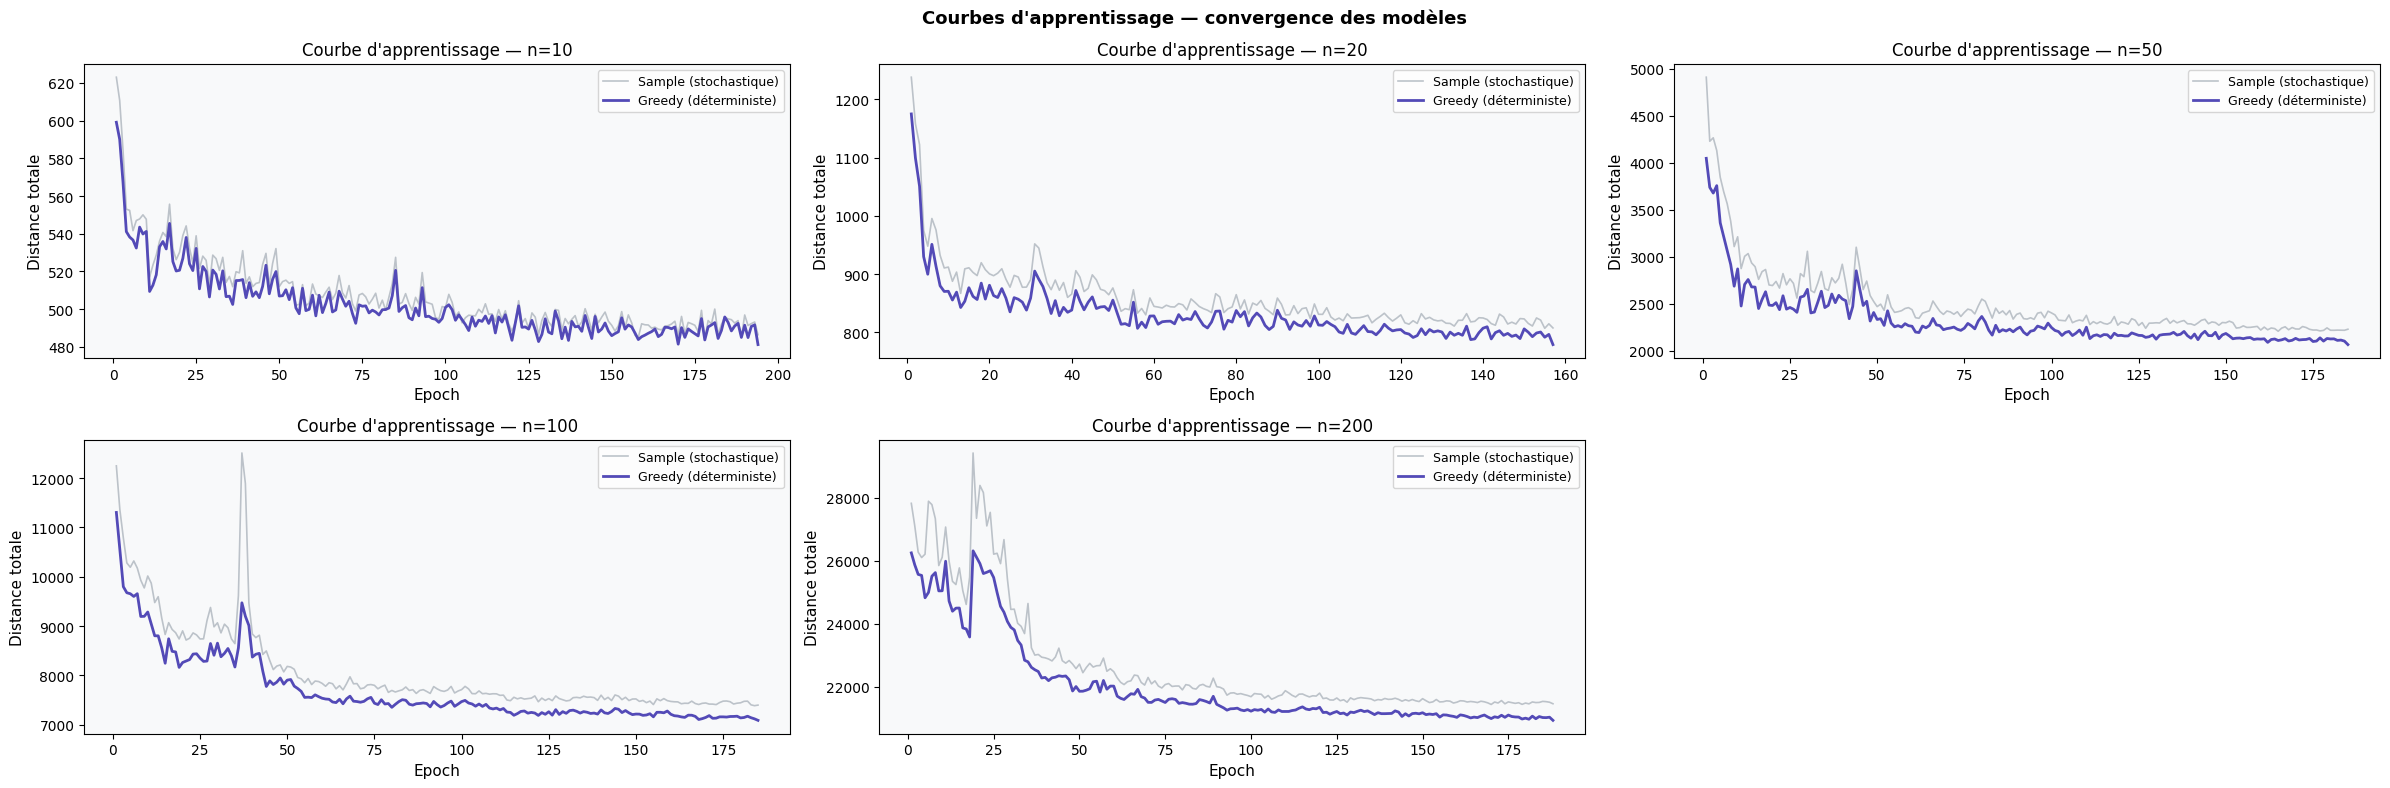

In [3]:
vdl.afficher_toutes_courbes_apprentissage(modeles)

## 3. Test rapide sur n=10 — 1 instance à la main

Vérification rapide avant de lancer la boucle complète.

Tournées par véhicule :
  Véhicule 0 : [0, 7, 9, 10, 0]
  Véhicule 1 : [0, 4, 8, 6, 1, 0]
  Véhicule 2 : [0, 5, 2, 3, 0]
Coût total      : 512.85
Temps inférence : 476.07 ms
Violations      : Aucune ✓


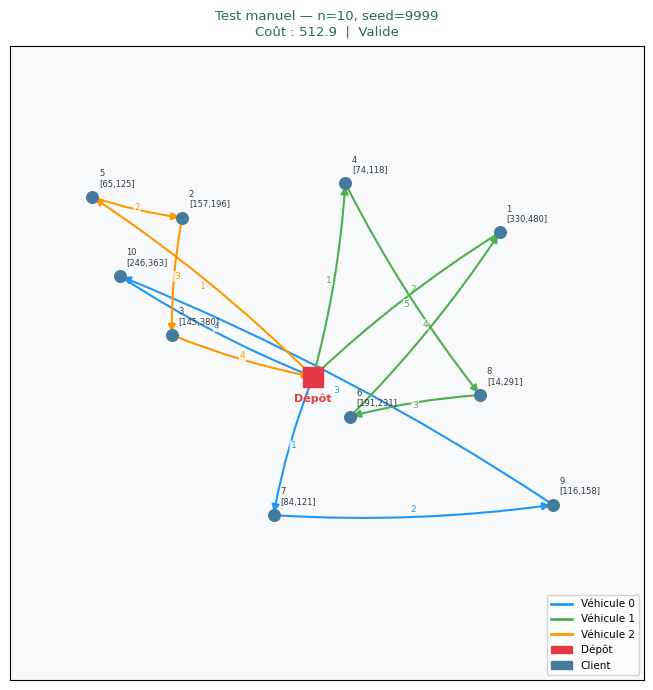

In [4]:
from preprocess import generate_instance

if 10 in modeles:
    model_10, _, _ = modeles[10]

    inst = generate_instance(n=10, n_vehicles=3, seed=9999)
    res  = vdl.inferer_tournee(model_10, inst, device=DEVICE, greedy=True)

    print('Tournées par véhicule :')
    for k, t in enumerate(res['tournees']):
        print(f'  Véhicule {k} : {t}')
    print(f'Coût total      : {res["cout_total"]:.2f}')
    print(f'Temps inférence : {res["temps_inference"]*1000:.2f} ms')
    print(f'Violations      : {res["violations"] if res["violations"] else "Aucune ✓"}')

    fig, ax = plt.subplots(figsize=(7, 7))
    vdl.afficher_tournee(inst, res, titre='Test manuel — n=10, seed=9999', ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('Modèle n=10 non chargé.')

## 4. Vérification complète — toutes les tailles

5 instances par taille, seeds 2000–2004 (jamais vus à l'entraînement).

In [6]:
rapport = vdl.run_verification_complete(
    modeles          = modeles,
    tailles          = sorted(modeles.keys()),
    n_instances_test = 5,
    n_vehicles       = 3,
    seed_offset      = 2000,
    device           = DEVICE,
)


 Vérification — n=10 clients  |  3 véhicules
  Inst 1 (seed=2000) | coût=  518.9 | t=26.6ms | déblocages=2 | OK
  Inst 2 (seed=2001) | coût=  467.9 | t=19.7ms | déblocages=0 | OK
  Inst 3 (seed=2002) | coût=  523.1 | t=18.2ms | déblocages=0 | OK
  Inst 4 (seed=2003) | coût=  559.6 | t=19.4ms | déblocages=0 | OK
  Inst 5 (seed=2004) | coût=  380.0 | t=19.2ms | déblocages=2 | OK

  Bilan n=10 : 5/5 valides (100%) | coût moy=489.9 ± 62.2 | t moy=20.6ms

 Vérification — n=20 clients  |  3 véhicules
  Inst 1 (seed=2000) | coût=  736.6 | t=41.9ms | déblocages=0 | OK
  Inst 2 (seed=2001) | coût=  810.5 | t=35.1ms | déblocages=1 | ERREUR (1 violation(s))
    → Clients non visités : [15]
  Inst 3 (seed=2002) | coût=  731.9 | t=36.3ms | déblocages=2 | ERREUR (1 violation(s))
    → Clients non visités : [11]
  Inst 4 (seed=2003) | coût=  985.1 | t=26.9ms | déblocages=1 | ERREUR (1 violation(s))
    → Clients non visités : [18]
  Inst 5 (seed=2004) | coût=  866.0 | t=19.9ms | déblocages=1 | ERREU

## 5. Visualisation des chemins multi-véhicules

In [ ]:
vdl.afficher_rapport_visuel(rapport, n_colonnes=3, max_par_taille=3)

## 6. Bilan global

## 7. Détail des violations

In [5]:
print('=== DÉTAIL DES VIOLATIONS PAR TAILLE ===\n')
for n in sorted(rapport.keys()):
    resultats = rapport[n]['resultats']
    avec_viol = [(k, r['violations']) for k, r in enumerate(resultats) if r['violations']]
    if not avec_viol:
        print(f'n={n} : toutes les tournées sont valides ✓')
    else:
        print(f'n={n} : {len(avec_viol)} instance(s) avec violations :')
        for k, viols in avec_viol:
            for v in viols:
                print(f'  Instance {k+1} → {v}')
    print()

=== DÉTAIL DES VIOLATIONS PAR TAILLE ===



NameError: name 'rapport' is not defined

## 8. Décision — Feu vert ou rouge ?

| Taux de validité | Interprétation | Décision |
|---|---|---|
| 100% partout | Modèle solide | ✅ Phase B (stats) |
| 80–99% | Quelques blocages TW / force_done | ⚠️ Acceptable, noter dans rapport |
| < 80% | Modèle non convergé ou env. mal géré | ❌ Déboguer avant |

In [ ]:
print('=== DÉCISION FINALE ===')
tout_ok = True
for n in sorted(rapport.keys()):
    taux = rapport[n]['bilan']['taux_validite']
    if taux == 1.0:
        print(f'  n={n:>3} : ✅  100% — PRÊT pour Phase B')
    elif taux >= 0.8:
        print(f'  n={n:>3} : ⚠️   {taux*100:.0f}% — Vérifier type de violations')
        tout_ok = False
    else:
        print(f'  n={n:>3} : ❌  {taux*100:.0f}% — DÉBOGUER avant Phase B')
        tout_ok = False
print()
print('→ FEU VERT : lancer phase_b_statistiques.ipynb' if tout_ok else
      '→ FEU ROUGE : corriger les modèles défaillants avant de continuer')